# Topic Modelling on E-Commerce Research Literature
## Manually Collected Dataset from Scopus

## Introduction

Topic Models are a type of statistical language model used for uncovering hidden thematic structure in a collection of texts. In practice, topic modelling serves as:

- **Dimensionality Reduction** — representing a document in a topic space rather than a raw word-frequency space
- **Unsupervised Learning** — similar to clustering, where clusters of words (topics) are discovered without labelled data
- **Tagging** — identifying abstract themes that best represent the information across a corpus

This notebook applies two topic modelling methods to a **manually collected dataset of 1,988 research paper abstracts** on the theme of *E-Commerce*, exported from the Scopus academic database. The two methods compared are:

1. **LDA (Latent Dirichlet Allocation)** — a generative probabilistic model using Gensim
2. **NMF (Non-negative Matrix Factorization)** — a deterministic matrix decomposition method using scikit-learn

### LDA Theoretical Overview
LDA assumes each topic is a mixture over an underlying set of words, and each document is a mixture over a set of topic probabilities.

Given M documents, N words, and K topics, LDA outputs:
- `psi` — distribution of words for each topic K
- `phi` — distribution of topics for each document

**Key Parameters:**
- `Alpha` — document-topic density (higher = documents cover more topics)
- `Beta` — topic-word density (higher = topics cover more words)

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

## Table of Contents

1. [Setup & Install Dependencies](#setup)
2. [Load Dataset from Google Drive](#load_data)
3. [Data Cleaning & Pre-processing](#clean_data)
4. [Exploratory Data Analysis](#eda)
5. [Prepare Text for Topic Modelling](#data_preparation)
6. [LDA Model Training](#lda_model)
7. [NMF Model Training](#nmf_model)
8. [Model Comparison & Visualisation](#results)
9. [Library Versions & Local Training Time (Task d)](#versions)

## Step 1: Setup & Install Dependencies <a class="anchor" id="setup"></a>

In [3]:
# Install required libraries
!pip install -q pyLDAvis gensim wordcloud nltk gdown

import pandas as pd
import numpy as np
import os
import re
import time
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from wordcloud import WordCloud
from collections import Counter

import pyLDAvis
import pyLDAvis.gensim_models

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to /home/fayzee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/fayzee/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/fayzee/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


All libraries imported successfully.


## Step 2: Load Dataset from Google Drive <a class="anchor" id="load_data"></a>

The dataset was manually collected from [Scopus](https://www.scopus.com) by searching for *'e-commerce'* in article titles, abstracts, and keywords. A total of **1,988 research paper abstracts** were exported as CSV, covering publications up to 2025.

In [4]:
# ── LOAD DATASET (Works on Google Colab AND Local Linux Environment) ──────────
import os, urllib.request

file_id = '1Ts-J0cdcdJIIJ19Qn1_cf1MmVUH1Spym'
output_path = 'eCommerceDatasetScopus.csv'

def download_from_gdrive(file_id, output_path):
    """Download a public Google Drive file — works on Colab and local machine."""
    try:
        import gdown
        url = f'https://drive.google.com/uc?id={file_id}&export=download'
        gdown.download(url, output_path, quiet=False)
        print(f"✓ Downloaded via gdown: {output_path}")
    except Exception as e:
        print(f"gdown failed ({e}), trying urllib fallback...")
        download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
        urllib.request.urlretrieve(download_url, output_path)
        print(f"✓ Downloaded via urllib: {output_path}")

if not os.path.exists(output_path):
    os.system('pip install -q gdown')
    download_from_gdrive(file_id, output_path)
else:
    print(f"✓ File already exists, skipping download: {output_path}")

# Load into DataFrame
papers = pd.read_csv(output_path)
print(f"\nDataset shape: {papers.shape}")
print(f"Columns: {papers.columns.tolist()}")
papers.head()

✓ File already exists, skipping download: eCommerceDatasetScopus.csv

Dataset shape: (1988, 6)
Columns: ['Title', 'Year', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']


,Title,Year,Link,Abstract,Author Keywords,Index Keywords
0,Exploring the Legal Framework for E-Commerce i...,2024,https://www.scopus.com/pages/publications/8521...,E-commerce in Nigeria is rapidly growing fuele...,E-commerce; legal framework; Malaysia; Nigeria...,Internet transaction; Legal frameworks; Malays...
1,Designing and Implementing a Trustless E-Comme...,2025,https://www.scopus.com/pages/publications/1050...,Medium-sized businesses in the apparel sector ...,Authenticity Verification; Blockchain; Non-Fun...,Authentication; Electronic commerce; Inventory...
2,Awareness and Use of Home-Based Respiratory Pa...,2026,https://www.scopus.com/pages/publications/1050...,Background: Home-based respiratory pathogen te...,home-based testing; internet-based health care...,NaN
3,Advancements in Eye Tracking for Visual Attent...,2025,https://www.scopus.com/pages/publications/1050...,The purpose of the paper is to explore the inf...,Cognitive load; Eye tracking; Human-computer i...,Electronic design automation; Mobile commerce;...
4,Freight and logistics grand challenges,2025,https://www.scopus.com/pages/publications/1050...,[No abstract available],city logistics; ecommerce; network efficiency;...,NaN


In [5]:
# Dataset overview
print("=== Dataset Overview ===")
print(f"Total papers  : {len(papers):,}")
print(f"Columns       : {papers.columns.tolist()}")
print(f"\nMissing values:\n{papers.isnull().sum()}")
print(f"\nYear range    : {papers['Year'].min()} – {papers['Year'].max()}")
papers.describe(include='all')

=== Dataset Overview ===
Total papers  : 1,988
Columns       : ['Title', 'Year', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']

Missing values:
Title                0
Year                 0
Link                 0
Abstract             0
Author Keywords    284
Index Keywords     701
dtype: int64

Year range    : 2018 – 2026


,Title,Year,Link,Abstract,Author Keywords,Index Keywords
count,1988,1988.000000,1988,1988,1704,1287
unique,1981,NaN,1988,1964,1697,1287
top,eCommerce,NaN,https://www.scopus.com/pages/publications/8521...,[No abstract available],association rule algorithm; data mining; ecomm...,Internet transaction; Legal frameworks; Malays...
freq,2,NaN,1,22,3,1
mean,NaN,2021.845070,NaN,NaN,NaN,NaN
std,NaN,2.259497,NaN,NaN,NaN,NaN
min,NaN,2018.000000,NaN,NaN,NaN,NaN
25%,NaN,2020.000000,NaN,NaN,NaN,NaN
50%,NaN,2022.000000,NaN,NaN,NaN,NaN
75%,NaN,2024.000000,NaN,NaN,NaN,NaN


## Step 3: Data Cleaning & Pre-processing <a class="anchor" id="clean_data"></a>

We focus on the **Abstract** column as the primary text source. Pre-processing steps include:
- Dropping rows with missing abstracts
- Removing copyright notices (e.g. `© 2024 IEEE`)
- Removing punctuation and special characters
- Lowercasing
- Removing stop words
- **Lemmatisation** — reducing words to their base form (e.g. *learning* → *learn*)

In [6]:
# Drop rows with missing abstracts
papers = papers.dropna(subset=['Abstract']).reset_index(drop=True)
print(f"Papers after dropping missing abstracts: {len(papers):,}")

# Remove copyright notices common in Scopus exports
papers['Abstract'] = papers['Abstract'].str.replace(
    r'©.*?(IEEE|Elsevier|Springer|ACM|Author|Rights Reserved).*', '', regex=True)

# Remove punctuation and lowercase
papers['abstract_processed'] = papers['Abstract'].map(
    lambda x: re.sub(r'[^a-zA-Z\s]', ' ', str(x)))
papers['abstract_processed'] = papers['abstract_processed'].map(
    lambda x: re.sub(r'\s+', ' ', x.lower()).strip())

print(f"\nSample cleaned abstract:\n{papers['abstract_processed'][0][:300]}")

Papers after dropping missing abstracts: 1,988

Sample cleaned abstract:
e commerce in nigeria is rapidly growing fueled by technological advancements increasing internet penetration and a growing acceptance of digital transactions among consumers however this robust market requires specific laws to address the challenges associated with online shopping this study review


## Step 4: Exploratory Data Analysis <a class="anchor" id="eda"></a>

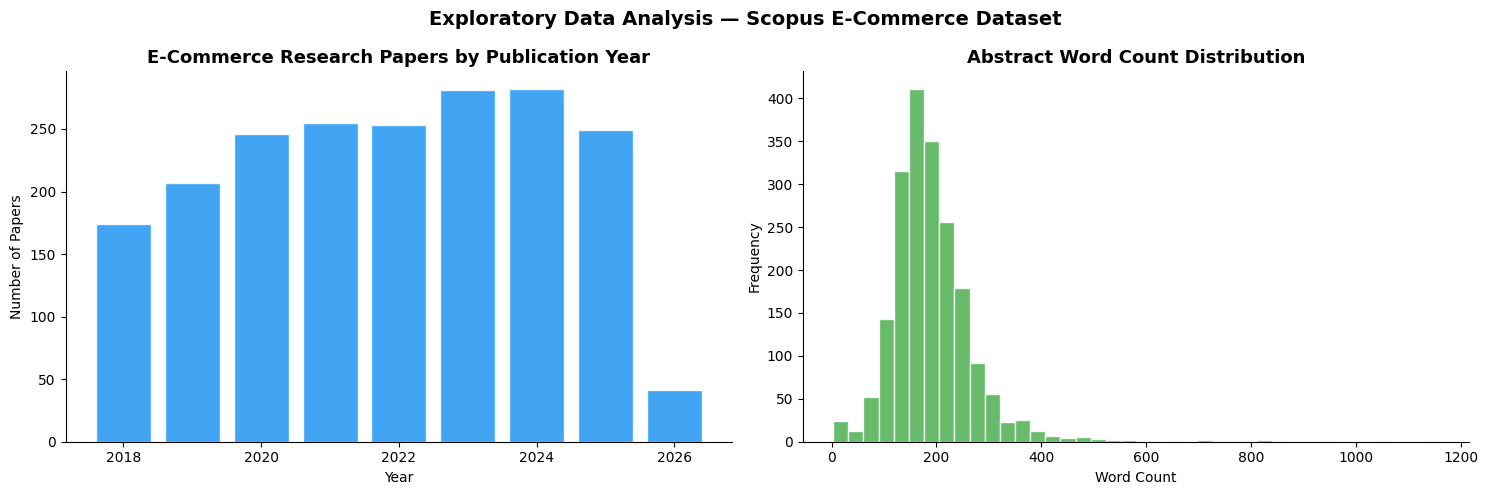

Average abstract length: 192 words
Min: 3 | Max: 1159


In [7]:
# ── Publication Year Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

year_counts = papers['Year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='#2196F3', alpha=0.85, edgecolor='white')
axes[0].set_title('E-Commerce Research Papers by Publication Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].spines[['top', 'right']].set_visible(False)

# Abstract word count distribution
papers['word_count'] = papers['abstract_processed'].apply(lambda x: len(x.split()))
axes[1].hist(papers['word_count'], bins=40, color='#4CAF50', alpha=0.85, edgecolor='white')
axes[1].set_title('Abstract Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Exploratory Data Analysis — Scopus E-Commerce Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average abstract length: {papers['word_count'].mean():.0f} words")
print(f"Min: {papers['word_count'].min()} | Max: {papers['word_count'].max()}")

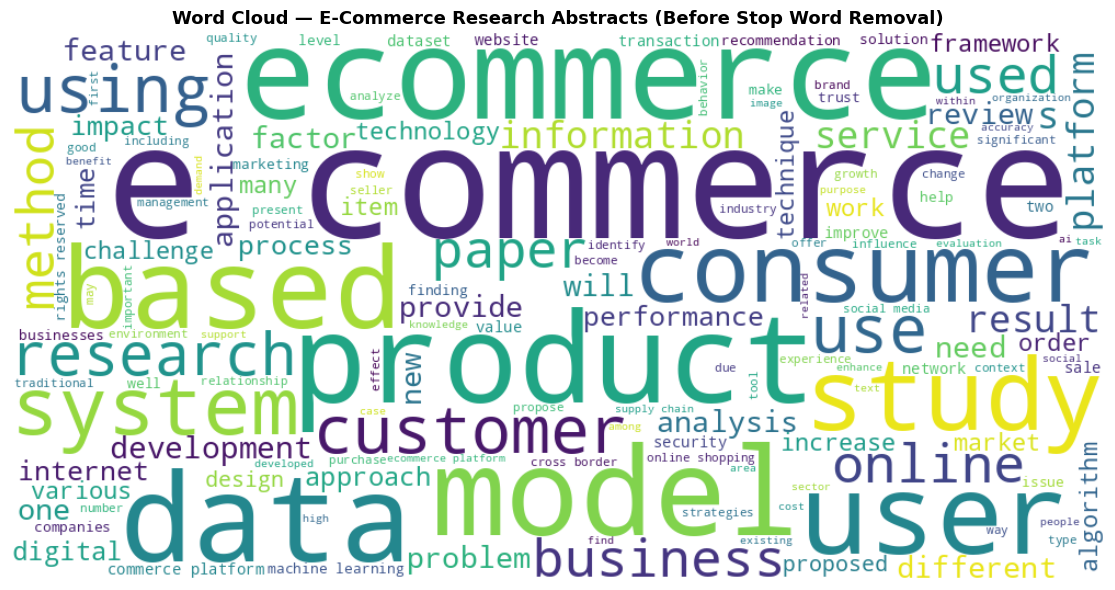

In [8]:
# ── Word Cloud of All Abstracts ───────────────────────────────────────
long_string = ' '.join(list(papers['abstract_processed'].values))

wordcloud = WordCloud(
    background_color="white", max_words=150,
    contour_width=3, contour_color='steelblue',
    width=1000, height=500, colormap='viridis'
)
wordcloud.generate(long_string)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — E-Commerce Research Abstracts (Before Stop Word Removal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

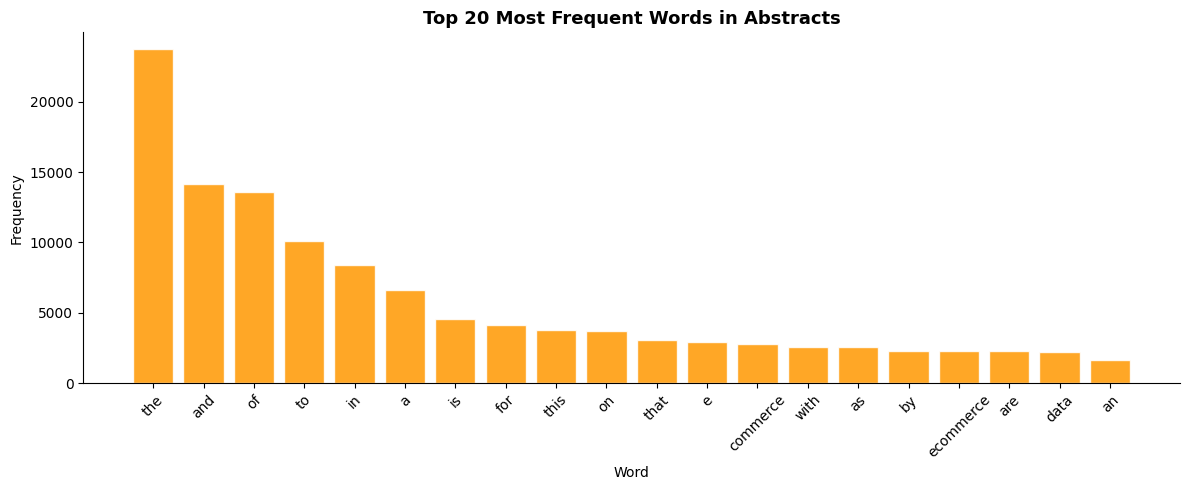

In [9]:
# ── Top 20 Most Frequent Words ────────────────────────────────────────
all_words = ' '.join(papers['abstract_processed'].values).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(words, freqs, color='#FF9800', alpha=0.85, edgecolor='white')
ax.set_title('Top 20 Most Frequent Words in Abstracts', fontsize=13, fontweight='bold')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 5: Prepare Text for Topic Modelling <a class="anchor" id="data_preparation"></a>

Using **Gensim** for tokenisation and stop word removal, followed by **lemmatisation** with NLTK's WordNetLemmatizer to reduce inflected words to their base form. This improves topic coherence by treating *'customer'* and *'customers'* as the same token.

In [10]:
# Extended stop words for academic e-commerce domain
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'used', 'using',
                   'study', 'paper', 'research', 'proposed', 'based', 'method',
                   'results', 'data', 'also', 'model', 'models', 'approach',
                   'result', 'show', 'shown', 'analysis', 'however', 'two',
                   'one', 'new', 'et', 'al', 'within', 'across', 'among'])

lemmatizer = WordNetLemmatizer()

def sent_to_words(sentences):
    """Tokenise sentences into word lists using Gensim simple_preprocess."""
    for sentence in sentences:
        yield gensim.utils.simple_preprocess(str(sentence), deacc=True)

def remove_stopwords(texts):
    """Remove stop words from tokenised texts."""
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]

def lemmatise(texts):
    """Lemmatise all tokens to their base form."""
    return [[lemmatizer.lemmatize(word) for word in doc] for doc in texts]

data = papers['abstract_processed'].values.tolist()
data_words = list(sent_to_words(data))
data_words = remove_stopwords(data_words)
data_words = lemmatise(data_words)

print(f"Total documents processed: {len(data_words):,}")
print(f"\nSample tokenised abstract (first 20 tokens):")
print(data_words[0][:20])

Total documents processed: 1,988

Sample tokenised abstract (first 20 tokens):
['commerce', 'nigeria', 'rapidly', 'growing', 'fueled', 'technological', 'advancement', 'increasing', 'internet', 'penetration', 'growing', 'acceptance', 'digital', 'transaction', 'consumer', 'robust', 'market', 'requires', 'specific', 'law']


In [11]:
# ── Build Gensim Dictionary and Corpus (for LDA) ─────────────────────
id2word = corpora.Dictionary(data_words)

# Filter extremes: remove very rare and very common words
id2word.filter_extremes(no_below=5, no_above=0.5)

texts = data_words
corpus = [id2word.doc2bow(text) for text in texts]

print(f"Dictionary size (unique tokens): {len(id2word):,}")
print(f"Corpus size (documents)         : {len(corpus):,}")
print(f"\nSample BoW for first document (first 10 terms):")
print(corpus[0][:10])

Dictionary size (unique tokens): 4,029
Corpus size (documents)         : 1,988

Sample BoW for first document (first 10 terms):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 3), (8, 1), (9, 1)]


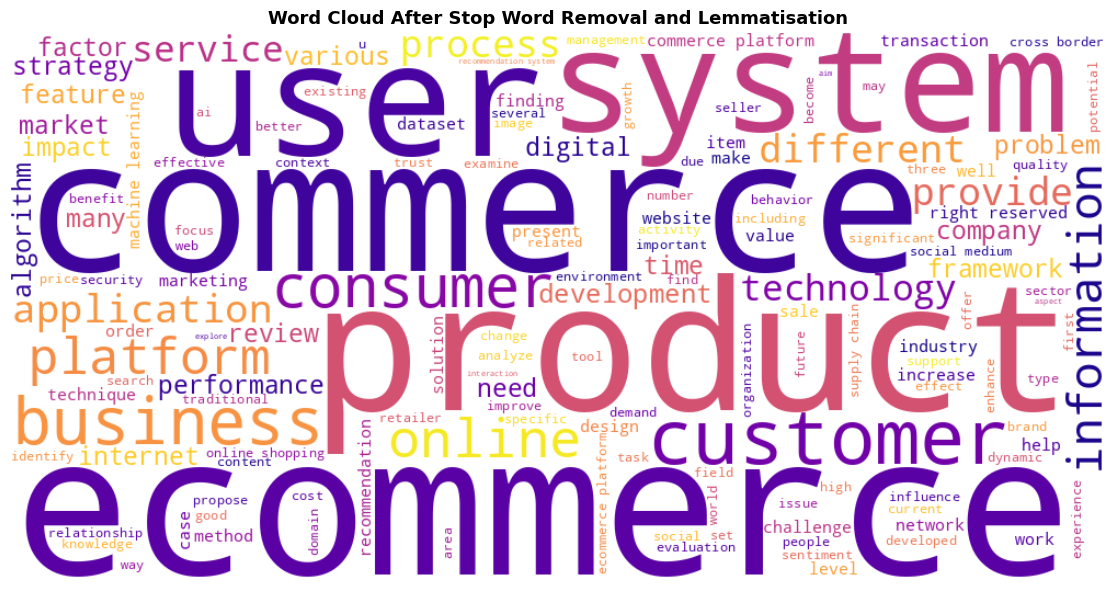

In [12]:
# ── Word Cloud After Pre-processing ──────────────────────────────────
clean_string = ' '.join([' '.join(doc) for doc in data_words])

wordcloud_clean = WordCloud(
    background_color="white", max_words=150,
    width=1000, height=500, colormap='plasma'
)
wordcloud_clean.generate(clean_string)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wordcloud_clean, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud After Stop Word Removal and Lemmatisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: LDA Model Training <a class="anchor" id="lda_model"></a>

LDA (Latent Dirichlet Allocation) is a **generative probabilistic model** that treats each document as a mixture of topics, and each topic as a mixture of words. We train using Gensim's `LdaMulticore` with **10 topics** and evaluate using **Coherence Score (C_v)** — a metric that measures how semantically similar the top words in each topic are.

In [13]:
# ── Train LDA Model ────────────────────────────────────────────────────
num_topics = 10

print(f"Training LDA model with {num_topics} topics...")
start_lda = time.time()

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=42,
    chunksize=100,
    passes=10,
    per_word_topics=True
)

lda_time = time.time() - start_lda
print(f"✓ LDA training complete — Time: {lda_time:.2f}s")

print("\n=== LDA Topics ===")
from pprint import pprint
pprint(lda_model.print_topics())

Training LDA model with 10 topics...


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:

✓ LDA training complete — Time: 4.43s

=== LDA Topics ===
[(0,
  '0.014*"system" + 0.008*"problem" + 0.007*"order" + 0.007*"delivery" + '
  '0.007*"logistics" + 0.007*"product" + 0.007*"commerce" + '
  '0.007*"application" + 0.006*"time" + 0.006*"process"'),
 (1,
  '0.020*"user" + 0.020*"product" + 0.015*"system" + 0.014*"recommendation" + '
  '0.011*"learning" + 0.010*"review" + 0.010*"algorithm" + 0.009*"feature" + '
  '0.008*"machine" + 0.007*"item"'),
 (2,
  '0.026*"customer" + 0.017*"online" + 0.012*"information" + 0.011*"website" + '
  '0.010*"user" + 0.009*"business" + 0.009*"product" + 0.009*"consumer" + '
  '0.009*"shopping" + 0.008*"commerce"'),
 (3,
  '0.025*"consumer" + 0.016*"online" + 0.012*"commerce" + 0.010*"shopping" + '
  '0.009*"digital" + 0.009*"technology" + 0.008*"intention" + 0.008*"business" '
  '+ 0.007*"ai" + 0.007*"platform"'),
 (4,
  '0.011*"application" + 0.010*"service" + 0.010*"network" + 0.010*"system" + '
  '0.010*"image" + 0.007*"security" + 0.007*"blo

In [14]:
# ── LDA Coherence Score ────────────────────────────────────────────────
coherence_model_lda = CoherenceModel(
    model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f"LDA Coherence Score (C_v): {coherence_lda:.4f}")
print("(Higher is better — typical range 0.4 to 0.7 for good models)")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2801) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:

LDA Coherence Score (C_v): 0.4358
(Higher is better — typical range 0.4 to 0.7 for good models)


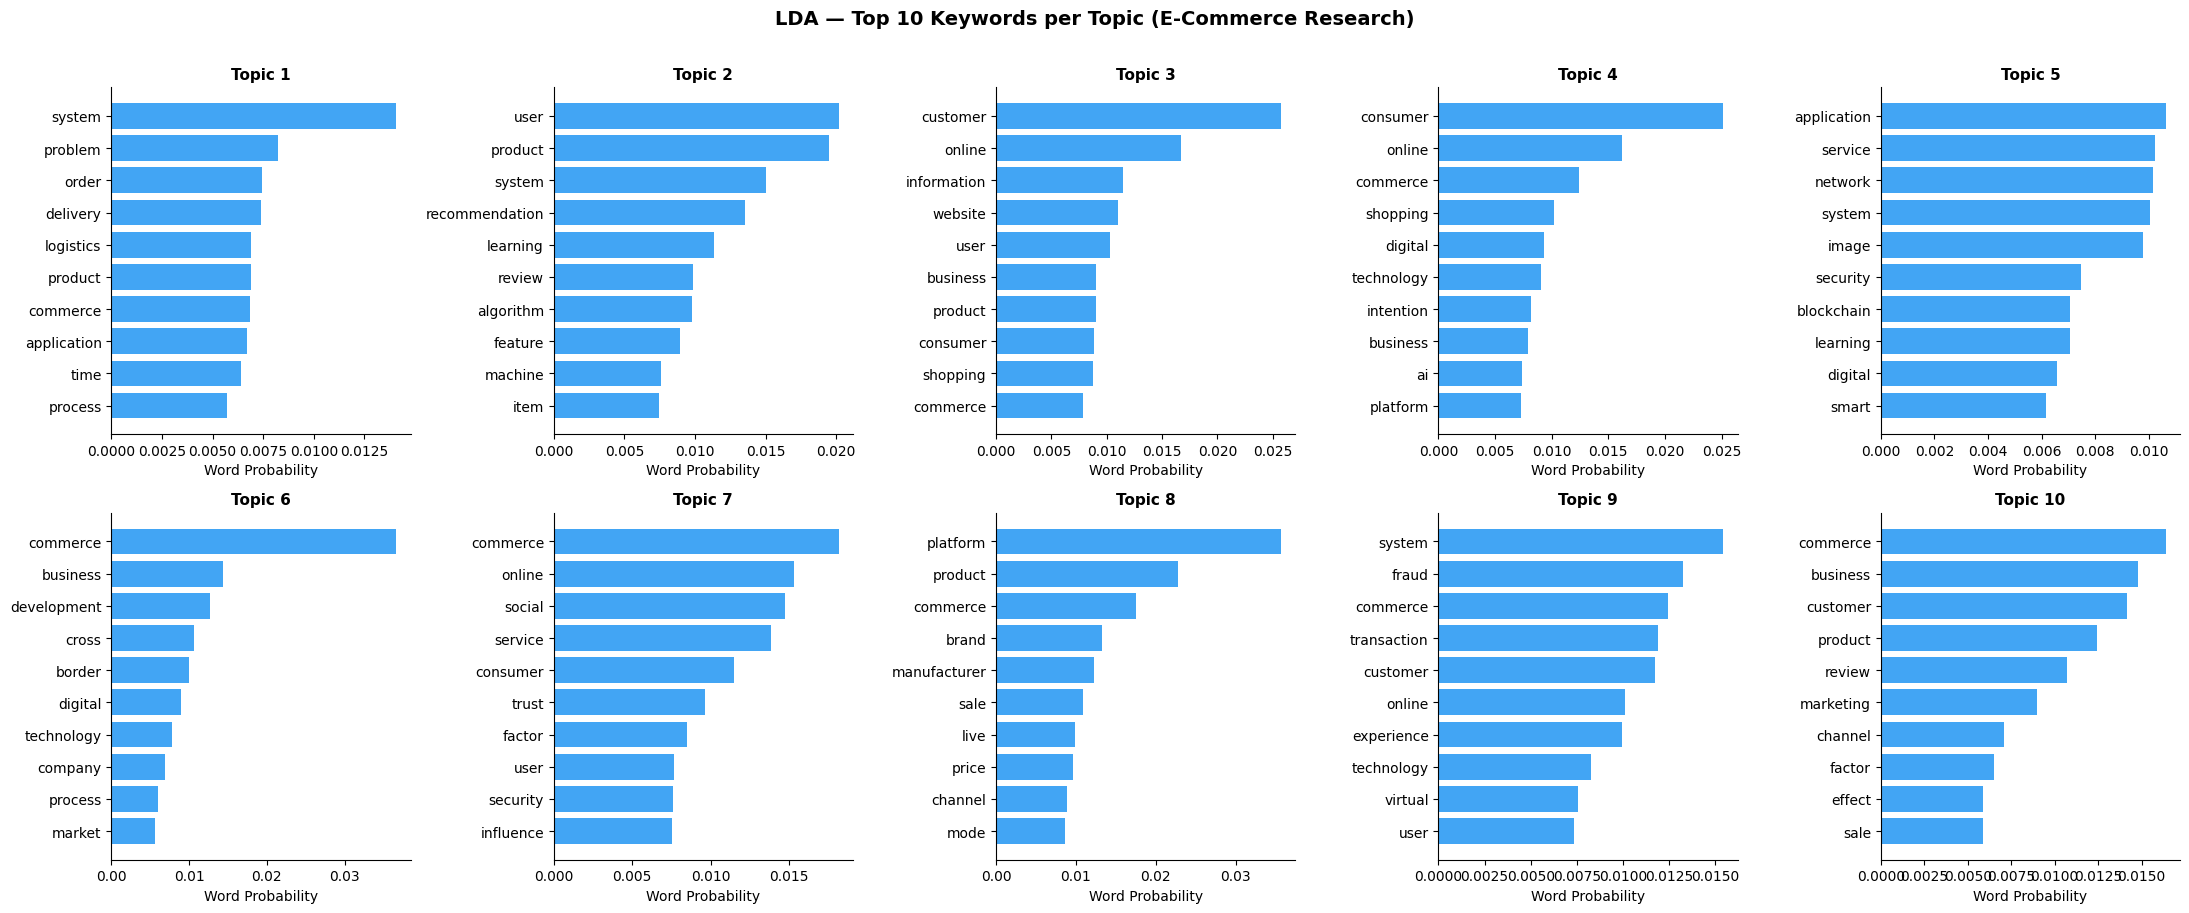

In [15]:
# ── LDA Topic Keywords Bar Charts ─────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for topic_id in range(num_topics):
    top_words = lda_model.show_topic(topic_id, topn=10)
    words = [w for w, _ in top_words]
    probs = [p for _, p in top_words]

    axes[topic_id].barh(words[::-1], probs[::-1], color='#2196F3', alpha=0.85)
    axes[topic_id].set_title(f'Topic {topic_id + 1}', fontsize=11, fontweight='bold')
    axes[topic_id].set_xlabel('Word Probability')
    axes[topic_id].spines[['top', 'right']].set_visible(False)

plt.suptitle('LDA — Top 10 Keywords per Topic (E-Commerce Research)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── pyLDAvis Interactive Visualisation ────────────────────────────────
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
pyLDAvis.display(lda_vis)

## Step 7: NMF Model Training <a class="anchor" id="nmf_model"></a>

NMF (Non-negative Matrix Factorization) is a **deterministic linear algebra** technique that decomposes a TF-IDF document-term matrix into two non-negative matrices representing topics and their word weights. Unlike LDA, NMF is not probabilistic — it produces the same results on every run and is generally faster. It tends to produce sharper, more focused topics, especially on shorter texts like abstracts.

In [17]:
# ── Build TF-IDF Matrix for NMF ───────────────────────────────────────
# NMF uses TF-IDF vectorisation (different from LDA's BoW)
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,          # ignore terms in more than 85% of docs
    min_df=5,             # ignore terms in fewer than 5 docs
    max_features=5000,    # top 5000 features
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(papers['abstract_processed'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"(documents × vocabulary terms)")

TF-IDF matrix shape: (1988, 4452)
(documents × vocabulary terms)


In [18]:
# ── Train NMF Model ────────────────────────────────────────────────────
num_topics_nmf = 10

print(f"Training NMF model with {num_topics_nmf} topics...")
start_nmf = time.time()

nmf_model = NMF(
    n_components=num_topics_nmf,
    random_state=42,
    max_iter=400,
    init='nndsvda'
)
nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

nmf_time = time.time() - start_nmf
print(f"✓ NMF training complete — Time: {nmf_time:.2f}s")

# Display topics
print("\n=== NMF Topics ===")
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [tfidf_feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Training NMF model with 10 topics...
✓ NMF training complete — Time: 0.66s

=== NMF Topics ===
Topic 1: commerce, business, adoption, development, study, smes, logistics, factors, rural, ecommerce
Topic 2: abstract, available, prediction, llms, information, publicly, models, various, matrix, queries
Topic 3: reviews, sentiment, product, review, text, analysis, opinion, products, opinions, customer
Topic 4: online, shopping, consumers, consumer, purchase, study, perceived, intention, behavior, research
Topic 5: recommendation, user, users, filtering, recommender, systems, collaborative, recommendations, product, item
Topic 6: border, cross, trade, commerce, china, logistics, development, foreign, cbec, international
Topic 7: learning, model, fraud, detection, machine, models, accuracy, using, proposed, based
Topic 8: social, media, marketing, digital, brand, study, influence, networks, consumer, information
Topic 9: data, security, web, blockchain, information, cloud, applications, tech

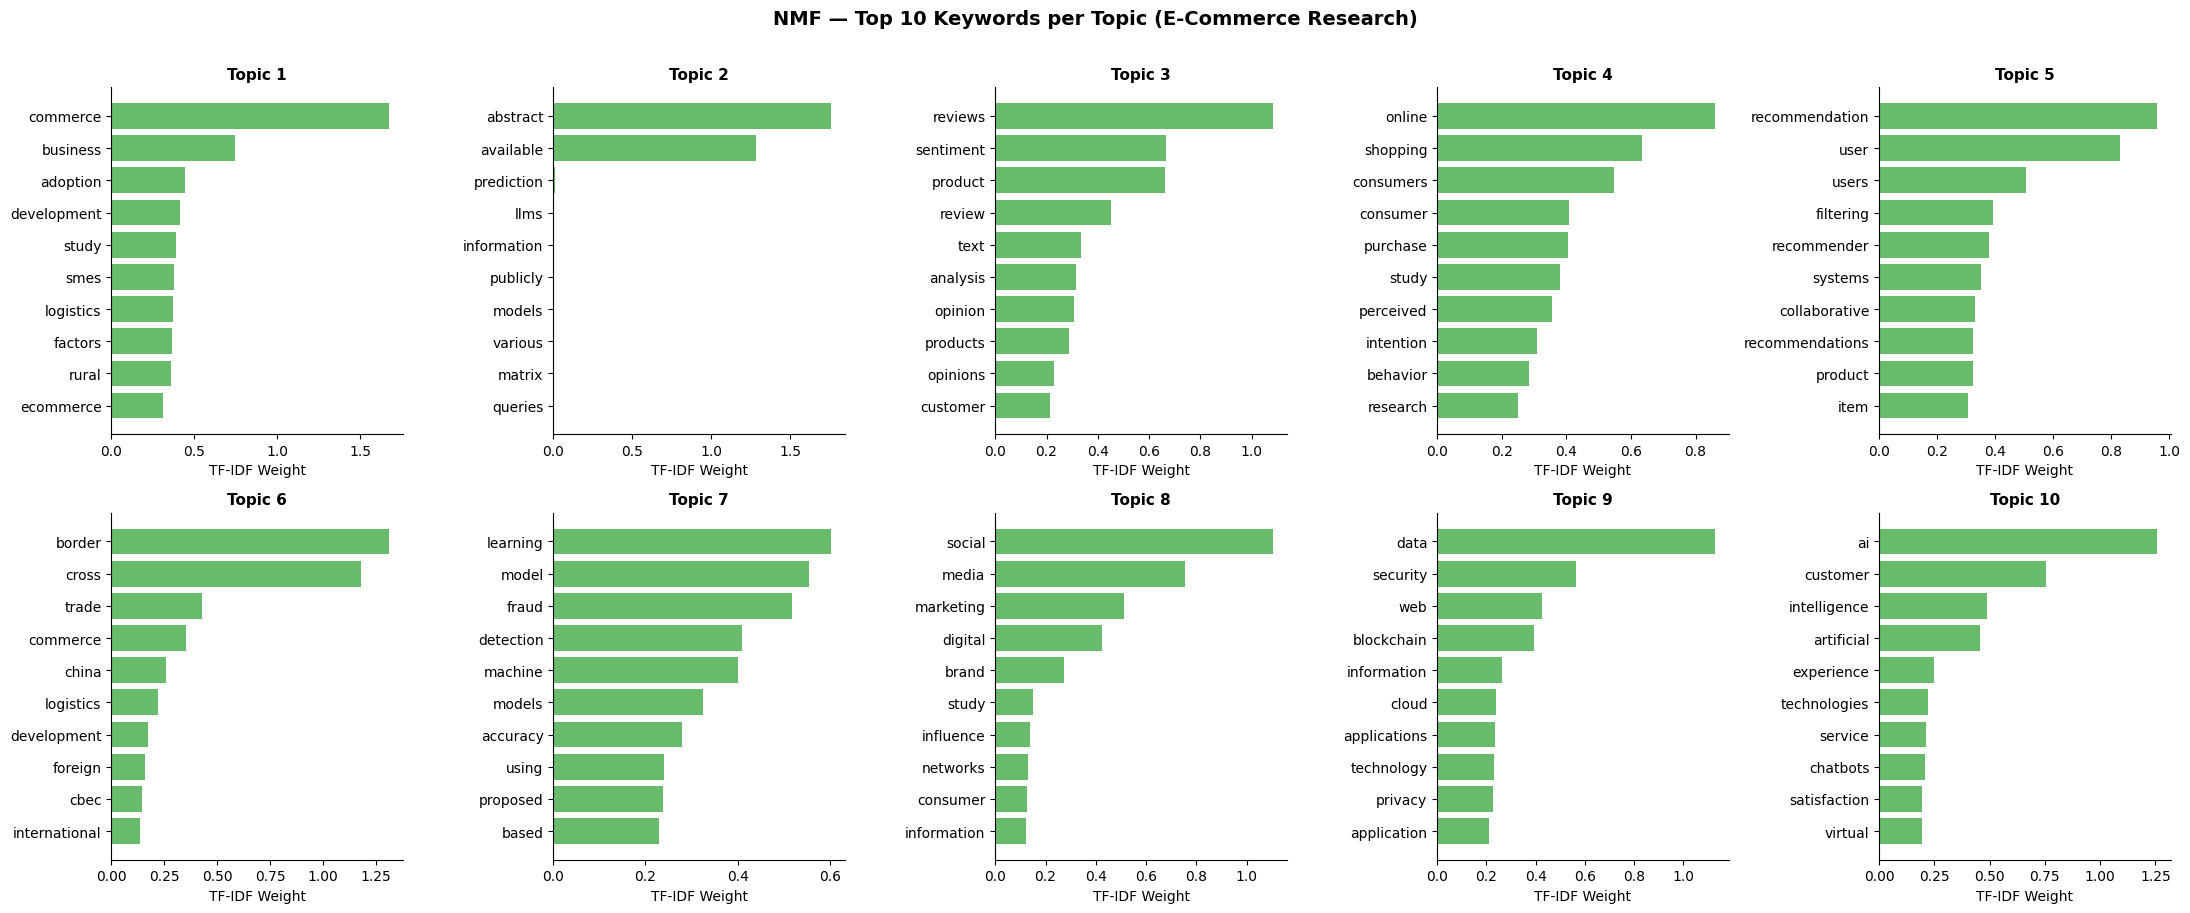

In [19]:
# ── NMF Topic Keywords Bar Charts ─────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for topic_id, topic in enumerate(nmf_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    words = [tfidf_feature_names[i] for i in top_indices]
    weights = [topic[i] for i in top_indices]

    axes[topic_id].barh(words[::-1], weights[::-1], color='#4CAF50', alpha=0.85)
    axes[topic_id].set_title(f'Topic {topic_id + 1}', fontsize=11, fontweight='bold')
    axes[topic_id].set_xlabel('TF-IDF Weight')
    axes[topic_id].spines[['top', 'right']].set_visible(False)

plt.suptitle('NMF — Top 10 Keywords per Topic (E-Commerce Research)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 8: Model Comparison & Visualisation <a class="anchor" id="results"></a>

In [20]:
# ── Summary Comparison Table ──────────────────────────────────────────
print("="*60)
print("  MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Metric':<35} {'LDA':>10} {'NMF':>10}")
print("-"*60)
print(f"{'Number of Topics':<35} {num_topics:>10} {num_topics_nmf:>10}")
print(f"{'Training Time (seconds)':<35} {lda_time:>10.2f} {nmf_time:>10.2f}")
print(f"{'Coherence Score (C_v) — LDA only':<35} {coherence_lda:>10.4f} {'N/A':>10}")
print(f"{'Vectorisation':<35} {'Bag-of-Words':>10} {'TF-IDF':>10}")
print(f"{'Deterministic':<35} {'No':>10} {'Yes':>10}")
print("="*60)
print("\nNote: NMF does not produce a direct coherence score via Gensim.")
print("NMF topic quality is evaluated visually via keyword interpretability.")

  MODEL COMPARISON SUMMARY
Metric                                     LDA        NMF
------------------------------------------------------------
Number of Topics                            10         10
Training Time (seconds)                   4.43       0.66
Coherence Score (C_v) — LDA only        0.4358        N/A
Vectorisation                       Bag-of-Words     TF-IDF
Deterministic                               No        Yes

Note: NMF does not produce a direct coherence score via Gensim.
NMF topic quality is evaluated visually via keyword interpretability.


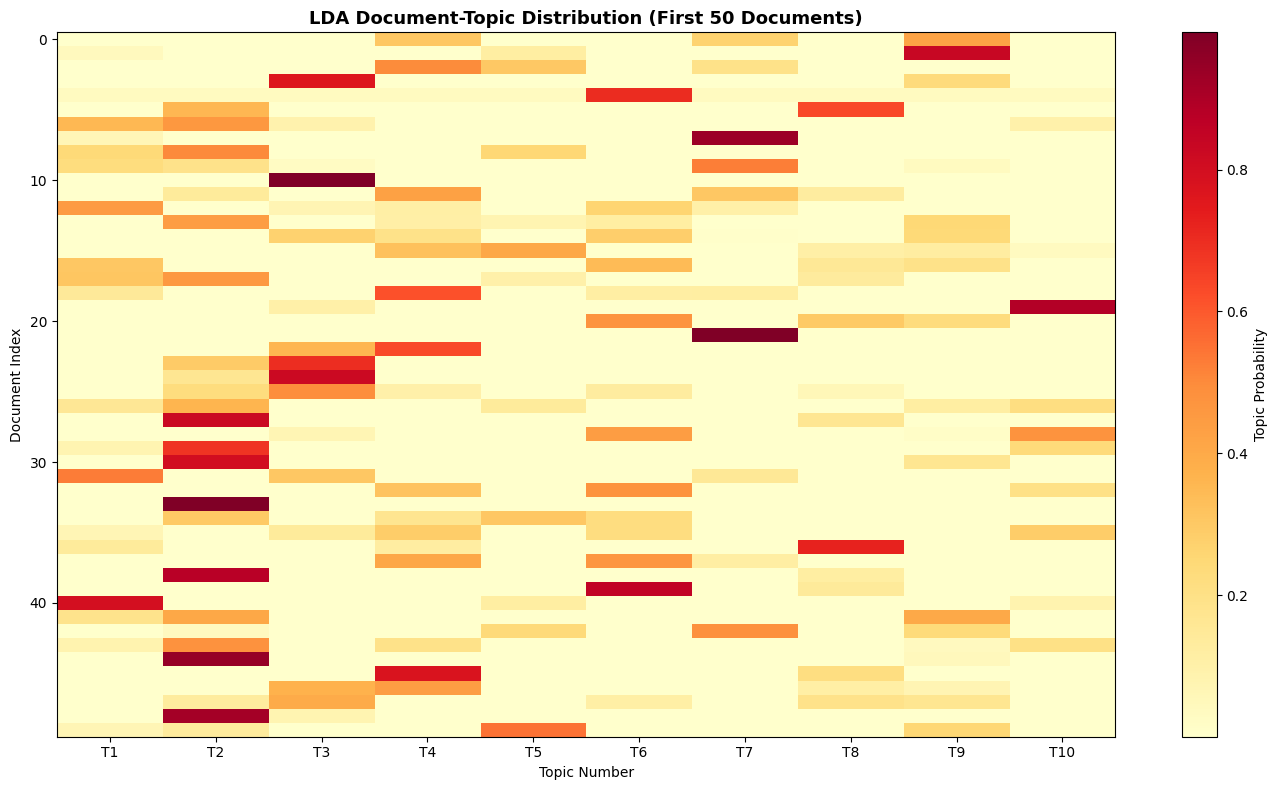

In [21]:
# ── Document-Topic Distribution Heatmap (LDA) ────────────────────────
lda_doc_topics = np.array([[prob for _, prob in lda_model.get_document_topics(
    doc, minimum_probability=0)] for doc in corpus[:50]])

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(lda_doc_topics, aspect='auto', cmap='YlOrRd')
ax.set_title('LDA Document-Topic Distribution (First 50 Documents)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Topic Number')
ax.set_ylabel('Document Index')
ax.set_xticks(range(num_topics))
ax.set_xticklabels([f'T{i+1}' for i in range(num_topics)])
plt.colorbar(im, ax=ax, label='Topic Probability')
plt.tight_layout()
plt.show()

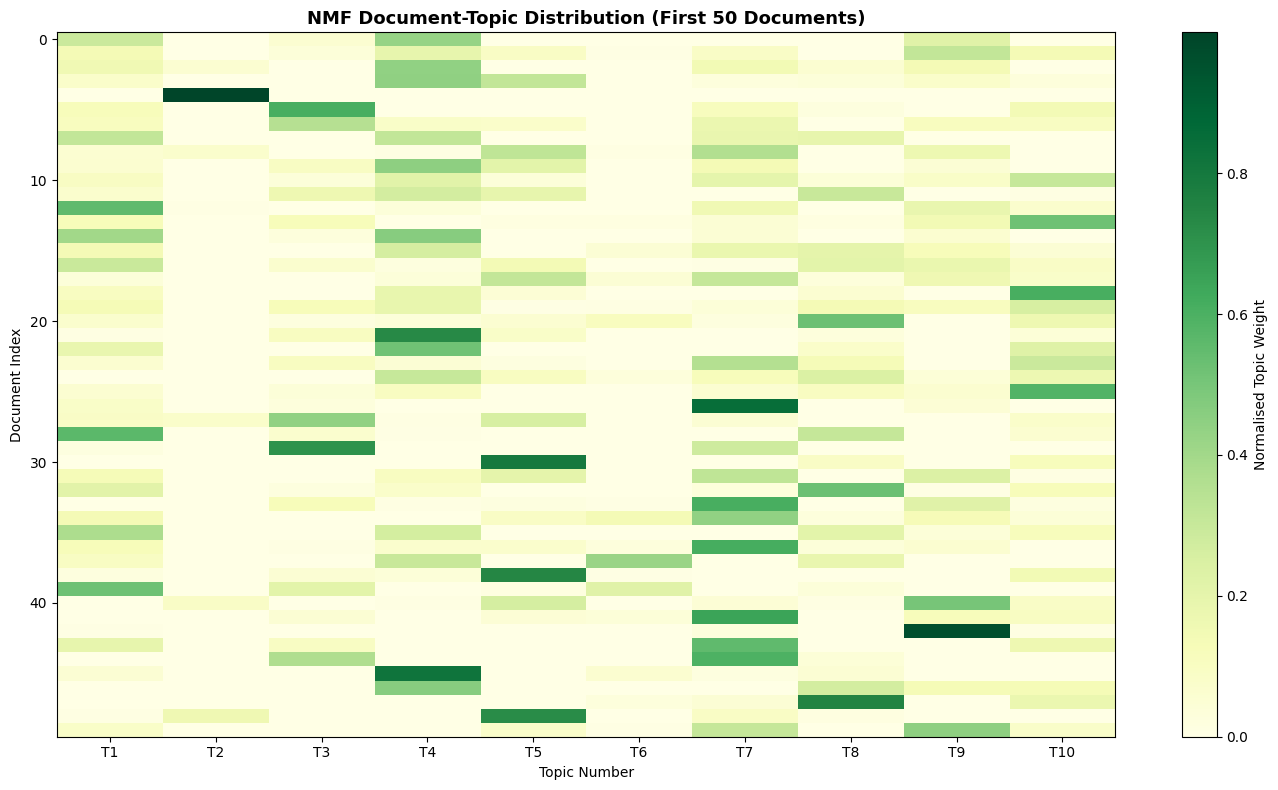

In [22]:
# ── Document-Topic Distribution Heatmap (NMF) ────────────────────────
nmf_doc_topics_norm = nmf_matrix[:50] / (nmf_matrix[:50].sum(axis=1, keepdims=True) + 1e-10)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(nmf_doc_topics_norm, aspect='auto', cmap='YlGn')
ax.set_title('NMF Document-Topic Distribution (First 50 Documents)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Topic Number')
ax.set_ylabel('Document Index')
ax.set_xticks(range(num_topics_nmf))
ax.set_xticklabels([f'T{i+1}' for i in range(num_topics_nmf)])
plt.colorbar(im, ax=ax, label='Normalised Topic Weight')
plt.tight_layout()
plt.show()

## Step 9: Library Versions & Local Training Time (Task d) <a class="anchor" id="versions"></a>

1. **Record the training times** printed above in Step 6
2. **Record the library versions** from the first cell below

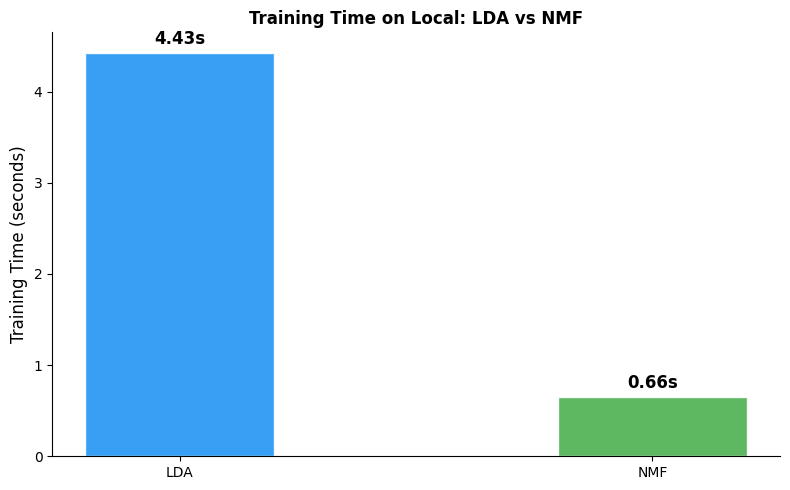

In [23]:
# ── Training Time Comparison Bar Chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
models = ['LDA', 'NMF']
times = [lda_time, nmf_time]
colors = ['#2196F3', '#4CAF50']

bars = ax.bar(models, times, color=colors, alpha=0.9, edgecolor='white', width=0.4)
ax.set_title('Training Time on Local: LDA vs NMF',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
import subprocess
result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)

key_libs = ['gensim', 'nltk', 'scikit-learn', 'sklearn', 'numpy', 'pandas',
            'matplotlib', 'pyldavis', 'wordcloud', 'gdown']

print("Key Library Versions (Task d):")
print("="*45)
for line in result.stdout.splitlines():
    for lib in key_libs:
        if line.lower().startswith(lib.lower()):
            print(line)
            break

print(f"   Local: LDA training time ({lda_time:.2f}s) and NMF ({nmf_time:.2f}s)")

Key Library Versions (Task d):
gdown==6.0.0
gensim==4.4.0
matplotlib==3.10.8
matplotlib-inline==0.2.1
nltk==3.9.4
numpy==2.4.4
pandas==3.0.2
pyLDAvis==3.4.1
scikit-learn==1.8.0
wordcloud==1.9.6
   Local: LDA training time (4.43s) and NMF (0.66s)
